In [1]:
import pandas as pd
from pathlib import Path
PROC = Path("../data/processed")

train = pd.read_csv(PROC / "train.csv")
val = pd.read_csv(PROC / "val.csv")
test = pd.read_csv(PROC / "test.csv")

print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")

total = len(train) + len(val) + len(test)
print(f"\nProporções: Train={len(train)/total:.2%}, Val={len(val)/total:.2%}, Test={len(test)/total:.2%}")

Train: (5038, 3), Val: (1080, 3), Test: (1080, 3)

Proporções: Train=69.99%, Val=15.00%, Test=15.00%


Train → 5038 exemplos | Real: 50.0% | Fake: 50.0%


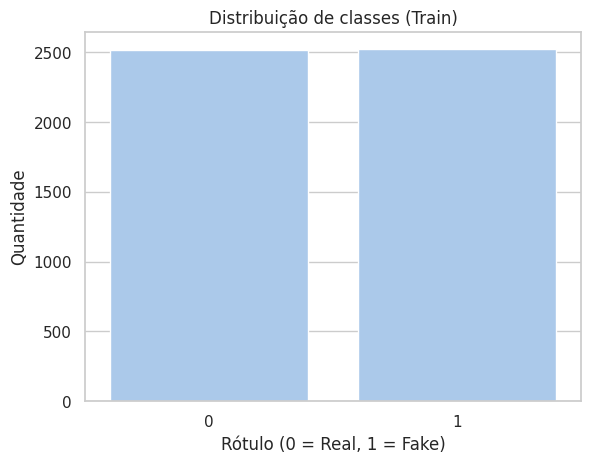

Validação → 1080 exemplos | Real: 50.0% | Fake: 50.0%


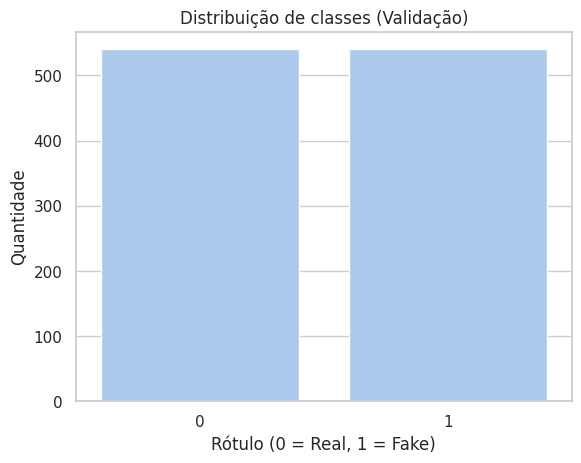

Teste → 1080 exemplos | Real: 50.0% | Fake: 50.0%


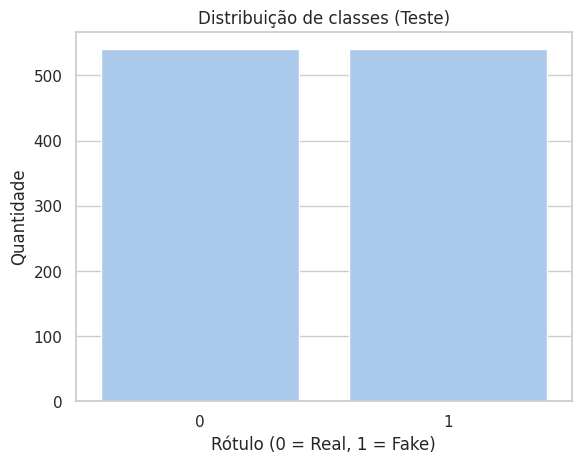

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="pastel")

for df, name in [(train, "Train"), (val, "Validação"), (test, "Teste")]:
    counts = df['label'].value_counts(normalize=True) * 100
    print(f"{name} → {df.shape[0]} exemplos | Real: {counts[0]:.1f}% | Fake: {counts[1]:.1f}%")
    sns.countplot(x="label", data=df)
    plt.title(f"Distribuição de classes ({name})")
    plt.xlabel("Rótulo (0 = Real, 1 = Fake)")
    plt.ylabel("Quantidade")
    plt.show()

Média de caracteres: 2832 | Mediana: 1596
Média de palavras: 367 | Mediana: 210


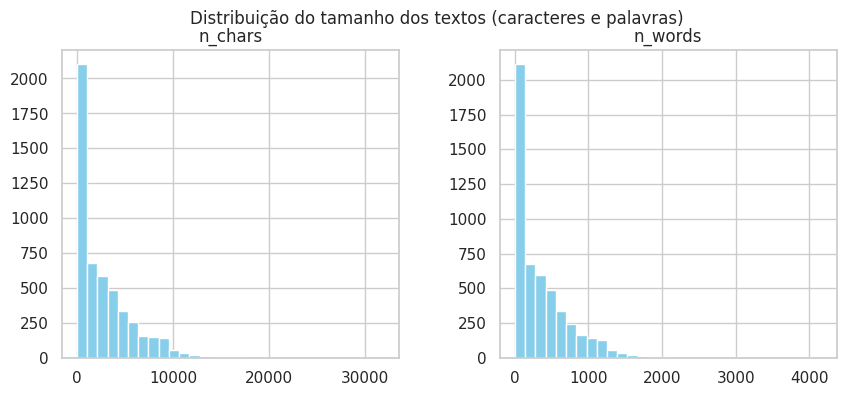

In [3]:
train['n_chars'] = train['text'].astype(str).map(len)
train['n_words'] = train['text'].astype(str).map(lambda t: len(str(t).split()))

print(f"Média de caracteres: {train['n_chars'].mean():.0f} | Mediana: {train['n_chars'].median():.0f}")
print(f"Média de palavras: {train['n_words'].mean():.0f} | Mediana: {train['n_words'].median():.0f}")

train[['n_chars', 'n_words']].hist(bins=30, figsize=(10,4), color='skyblue')
plt.suptitle("Distribuição do tamanho dos textos (caracteres e palavras)", fontsize=12)
plt.show()

In [4]:
# Mostrar 3 exemplos de FAKE e 3 de REAL
print("Fake examples:")
display(train[train.label == 1].sample(3, random_state=42)[['text']])

print("Real examples:")
display(train[train.label == 0].sample(3, random_state=42)[['text']])

Fake examples:


,text
432,fatima filho anos estariam deprimidos medica o...
1961,brasileiros serao cotados colonizar marte sera...
2166,vereadora psdb flagrada carregando produtos fu...


Real examples:


,text
4391,dono jbs gravou temer dando aval comprar silen...
819,cela onde eike batista preso bangu ventilador ...
2805,entenda pec fim foro privilegiado perguntas re...
